# Análisis Exploratorio de Datos (EDA) - US Vehicles

Este notebook contiene el análisis exploratorio de datos en Python Jupyter Notebook sobre vehículos usados en Estados Unidos para su posterior despliegue en render.

## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Configurar pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Configurar matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 2. Cargar datos

In [2]:
# Cargar el CSV
df = pd.read_csv('../data/raw/vehicles_us.csv')

# Mostrar información básica
print(f"Forma del dataset: {df.shape}")
print(f"\nColumnas:\n{df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head()

Forma del dataset: (51525, 13)

Columnas:
['price', 'model_year', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'transmission', 'type', 'paint_color', 'is_4wd', 'date_posted', 'days_listed']

Primeras filas:


,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed
0,9400,2011.0,bmw x5,good,6.0,gas,145000.0,automatic,SUV,NaN,1.0,2018-06-23,19
1,25500,NaN,ford f-150,good,6.0,gas,88705.0,automatic,pickup,white,1.0,2018-10-19,50
2,5500,2013.0,hyundai sonata,like new,4.0,gas,110000.0,automatic,sedan,red,NaN,2019-02-07,79
3,1500,2003.0,ford f-150,fair,8.0,gas,NaN,automatic,pickup,NaN,NaN,2019-03-22,9
4,14900,2017.0,chrysler 200,excellent,4.0,gas,80903.0,automatic,sedan,black,NaN,2019-04-02,28


## 3. Información del Dataset

In [3]:
# HISTOGRAMA CON PLOTLY-EXPRESS
fig = px.histogram(df, x='price', nbins=50,
                   title='Distribución de Precios de Vehículos',
                   labels={'price': 'Precio ($)'},
                   color_discrete_sequence=['#3498db'])
fig.update_layout(height=500, hovermode='x unified')
fig.show()

In [4]:
# GRÁFICO DE DISPERSIÓN CON PLOTLY-EXPRESS

# Scatter 1: Año del Modelo vs Precio
df_clean = df.dropna(subset=['model_year', 'price'])
fig = px.scatter(df_clean, x='model_year', y='price',
                 title='Año del Modelo vs Precio',
                 labels={'model_year': 'Año del Modelo', 'price': 'Precio ($)'},
                 opacity=0.6, color_discrete_sequence=['#3498db'])
fig.update_layout(height=500, hovermode='closest')
fig.show()

# Scatter 2: Cilindros vs Precio (coloreado por tipo)
df_scatter = df.dropna(subset=['cylinders', 'price', 'type'])
fig = px.scatter(df_scatter, x='cylinders', y='price', color='type',
                 title='Cilindros vs Precio (por Tipo de Vehículo)',
                 labels={'cylinders': 'Número de Cilindros', 'price': 'Precio ($)'})
fig.update_layout(height=500)
fig.show()

In [5]:
# Resumen estadístico
print("Resumen estadístico:")
print(df.describe())

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nTipos de datos:")
print(df.dtypes)

Resumen estadístico:
               price    model_year     cylinders       odometer   is_4wd  \
count   51525.000000  47906.000000  46265.000000   43633.000000  25572.0   
mean    12132.464920   2009.750470      6.125235  115553.461738      1.0   
std     10040.803015      6.282065      1.660360   65094.611341      0.0   
min         1.000000   1908.000000      3.000000       0.000000      1.0   
25%      5000.000000   2006.000000      4.000000   70000.000000      1.0   
50%      9000.000000   2011.000000      6.000000  113000.000000      1.0   
75%     16839.000000   2014.000000      8.000000  155000.000000      1.0   
max    375000.000000   2019.000000     12.000000  990000.000000      1.0   

       days_listed  
count  51525.00000  
mean      39.55476  
std       28.20427  
min        0.00000  
25%       19.00000  
50%       33.00000  
75%       53.00000  
max      271.00000  

Valores faltantes:
price               0
model_year       3619
model               0
condition          

## 4. HISTOGRAMAS

### 4.1 Histograma Básico - Distribución de Precios

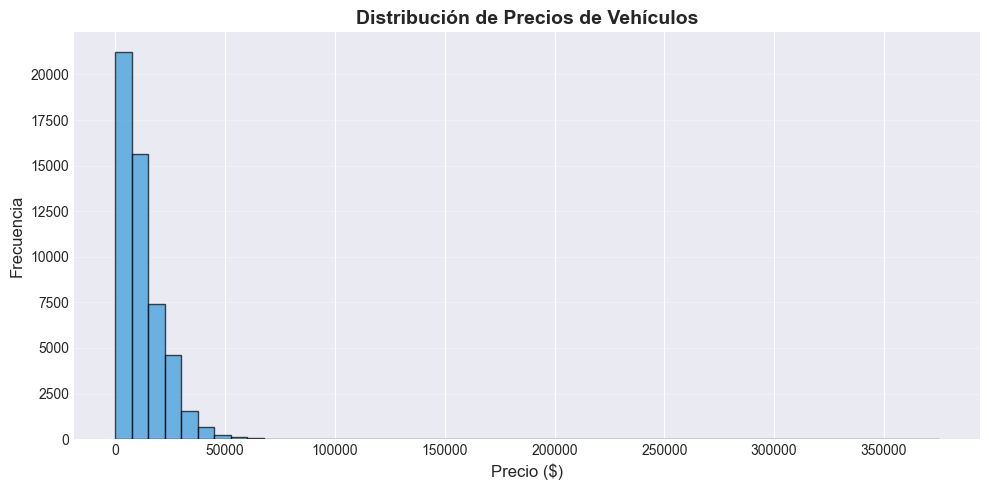

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
plt.title('Distribución de Precios de Vehículos', fontsize=14, fontweight='bold')
plt.xlabel('Precio ($)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Histograma - Año del Modelo

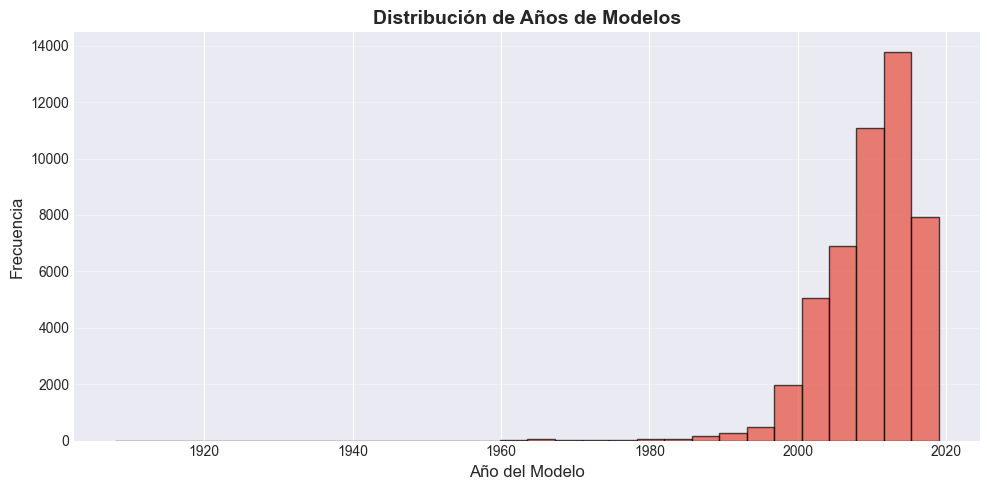

In [7]:
df_year = df.dropna(subset=['model_year'])

plt.figure(figsize=(10, 5))
plt.hist(df_year['model_year'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
plt.title('Distribución de Años de Modelos', fontsize=14, fontweight='bold')
plt.xlabel('Año del Modelo', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Histograma - Cilindros

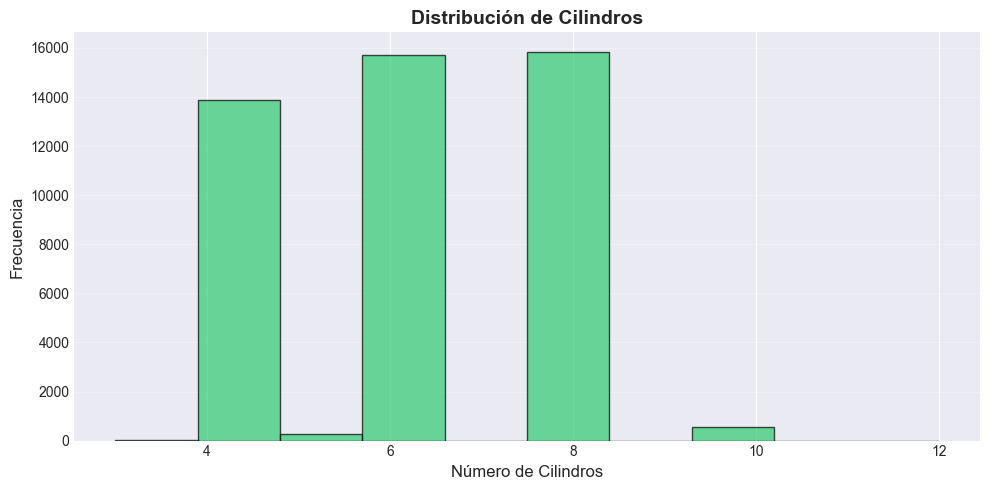

In [8]:
df_cyl = df.dropna(subset=['cylinders'])

plt.figure(figsize=(10, 5))
plt.hist(df_cyl['cylinders'], bins=10, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribución de Cilindros', fontsize=14, fontweight='bold')
plt.xlabel('Número de Cilindros', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Histogramas por Tipo de Vehículo (Facetas)

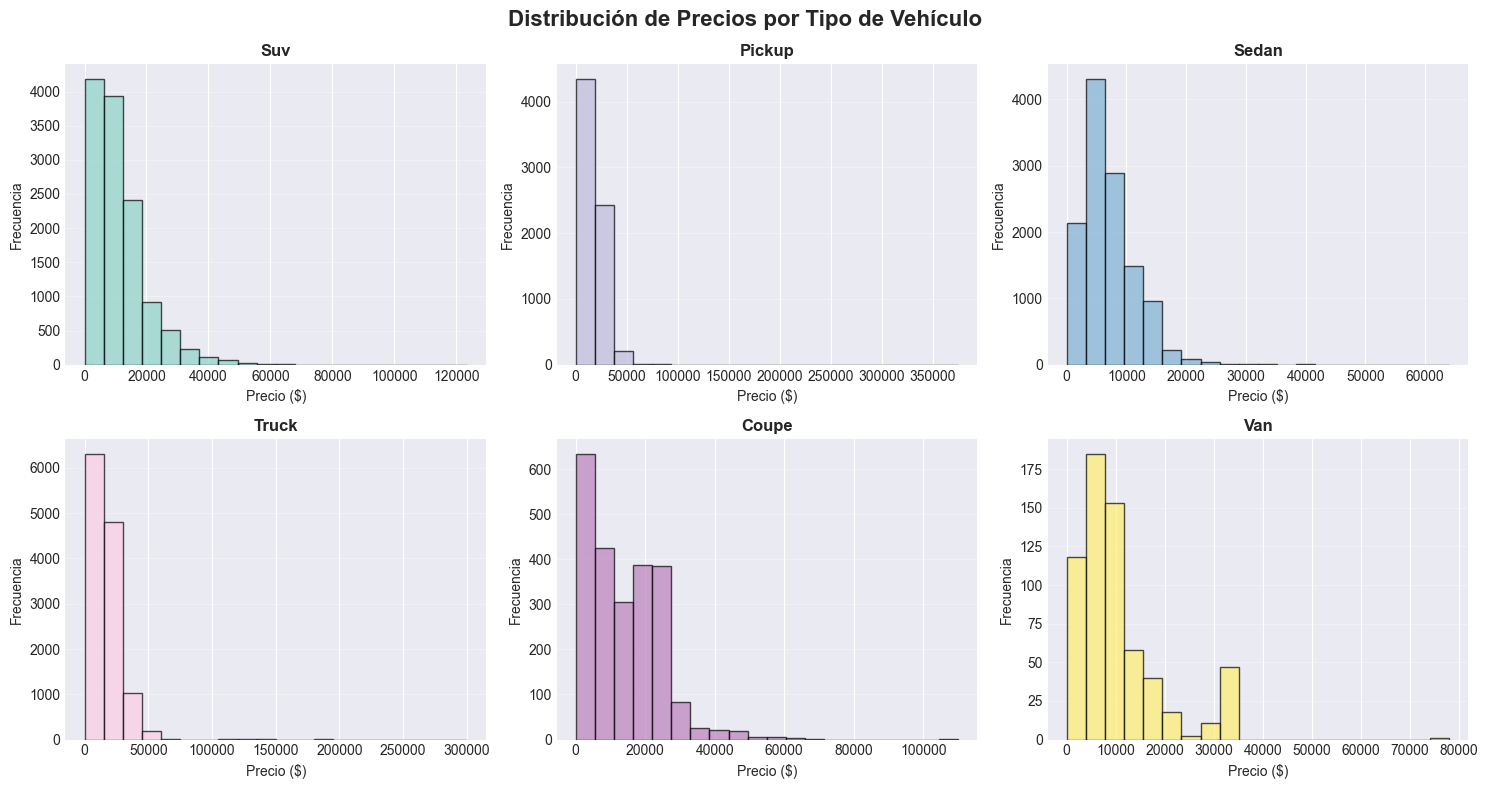

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribución de Precios por Tipo de Vehículo', fontsize=16, fontweight='bold')

vehicle_types = df['type'].unique()[:6]
colors = plt.cm.Set3(np.linspace(0, 1, len(vehicle_types)))

for idx, (ax, vtype) in enumerate(zip(axes.flat, vehicle_types)):
    data = df[df['type'] == vtype]['price'].dropna()
    ax.hist(data, bins=20, color=colors[idx], edgecolor='black', alpha=0.7)
    ax.set_title(f'{vtype.capitalize()}', fontweight='bold')
    ax.set_xlabel('Precio ($)', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. GRÁFICOS DE DISPERSIÓN (SCATTER)

### 5.1 Scatter Básico - Año vs Precio

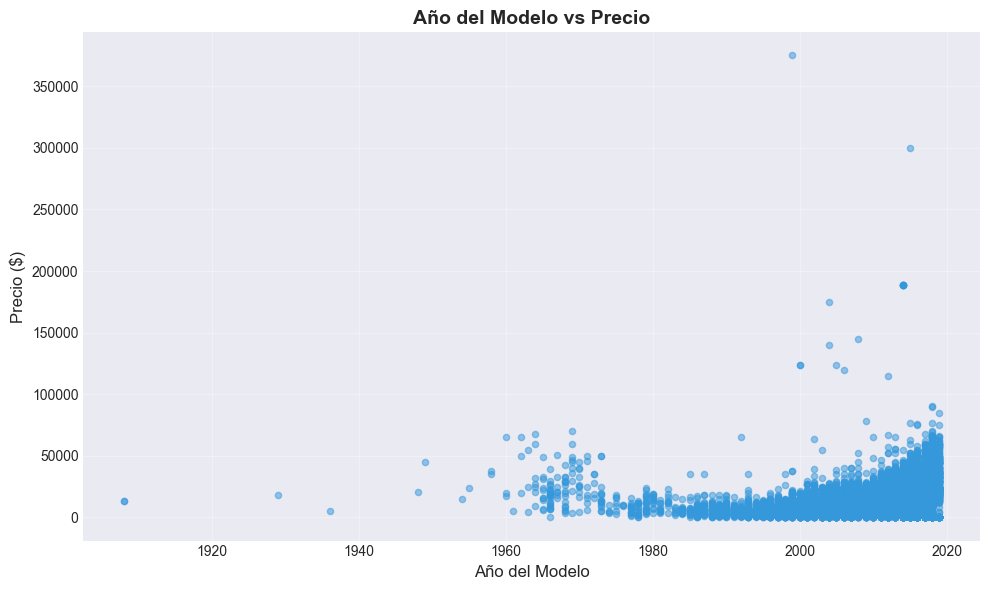

In [10]:
df_clean = df.dropna(subset=['model_year', 'price'])

plt.figure(figsize=(10, 6))
plt.scatter(df_clean['model_year'], df_clean['price'], alpha=0.5, s=20, color='#3498db')
plt.title('Año del Modelo vs Precio', fontsize=14, fontweight='bold')
plt.xlabel('Año del Modelo', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Scatter - Precio vs Cilindros (coloreado por tipo)

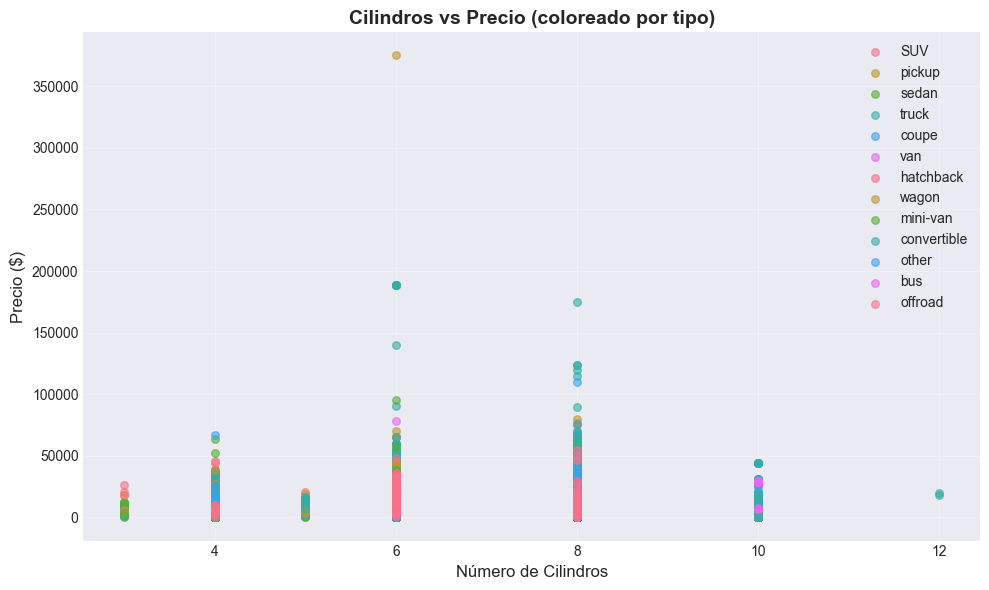

In [11]:
df_scatter = df.dropna(subset=['cylinders', 'price', 'type'])

plt.figure(figsize=(10, 6))
for vtype in df_scatter['type'].unique():
    data = df_scatter[df_scatter['type'] == vtype]
    plt.scatter(data['cylinders'], data['price'], label=vtype, alpha=0.6, s=30)

plt.title('Cilindros vs Precio (coloreado por tipo)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Cilindros', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Scatter - Días Listado vs Precio

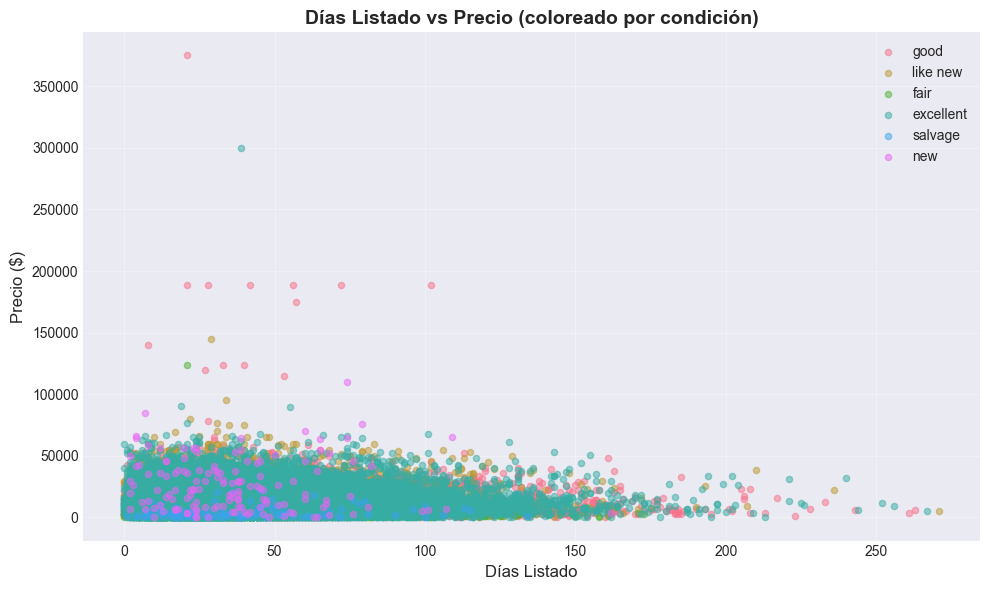

In [12]:
df_scatter2 = df.dropna(subset=['days_listed', 'price'])

plt.figure(figsize=(10, 6))
for cond in df_scatter2['condition'].unique():
    data = df_scatter2[df_scatter2['condition'] == cond]
    plt.scatter(data['days_listed'], data['price'], label=cond, alpha=0.5, s=20)

plt.title('Días Listado vs Precio (coloreado por condición)', fontsize=14, fontweight='bold')
plt.xlabel('Días Listado', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Scatter - Transmisión vs Año vs Precio

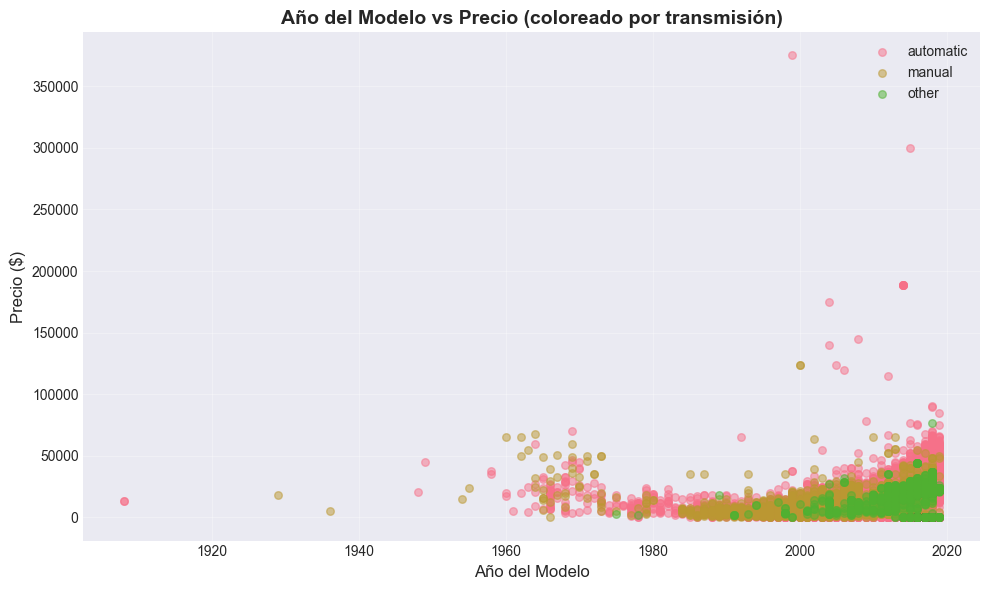

In [13]:
df_scatter3 = df.dropna(subset=['model_year', 'price', 'transmission'])

plt.figure(figsize=(10, 6))
for trans in df_scatter3['transmission'].unique():
    data = df_scatter3[df_scatter3['transmission'] == trans]
    plt.scatter(data['model_year'], data['price'], label=trans, alpha=0.5, s=30)

plt.title('Año del Modelo vs Precio (coloreado por transmisión)', fontsize=14, fontweight='bold')
plt.xlabel('Año del Modelo', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 Scatter com tamaño variable (año vs precio, tamaño = cilindros)

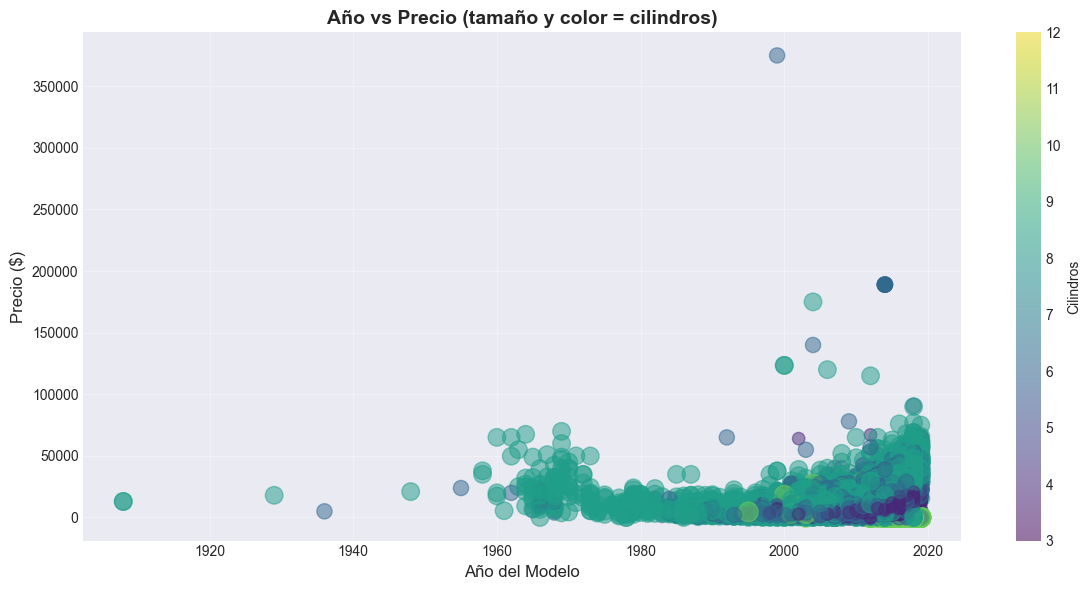

In [14]:
df_scatter4 = df.dropna(subset=['model_year', 'price', 'cylinders'])

plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_scatter4['model_year'], 
                      df_scatter4['price'],
                      s=df_scatter4['cylinders']*20,  # Tamaño proporcional a cilindros
                      alpha=0.5, 
                      c=df_scatter4['cylinders'],
                      cmap='viridis')

plt.title('Año vs Precio (tamaño y color = cilindros)', fontsize=14, fontweight='bold')
plt.xlabel('Año del Modelo', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
cbar = plt.colorbar(scatter)
cbar.set_label('Cilindros', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. GRÁFICOS ADICIONALES

### 6.1 Box Plot - Precio por Tipo

<Figure size 1200x600 with 0 Axes>

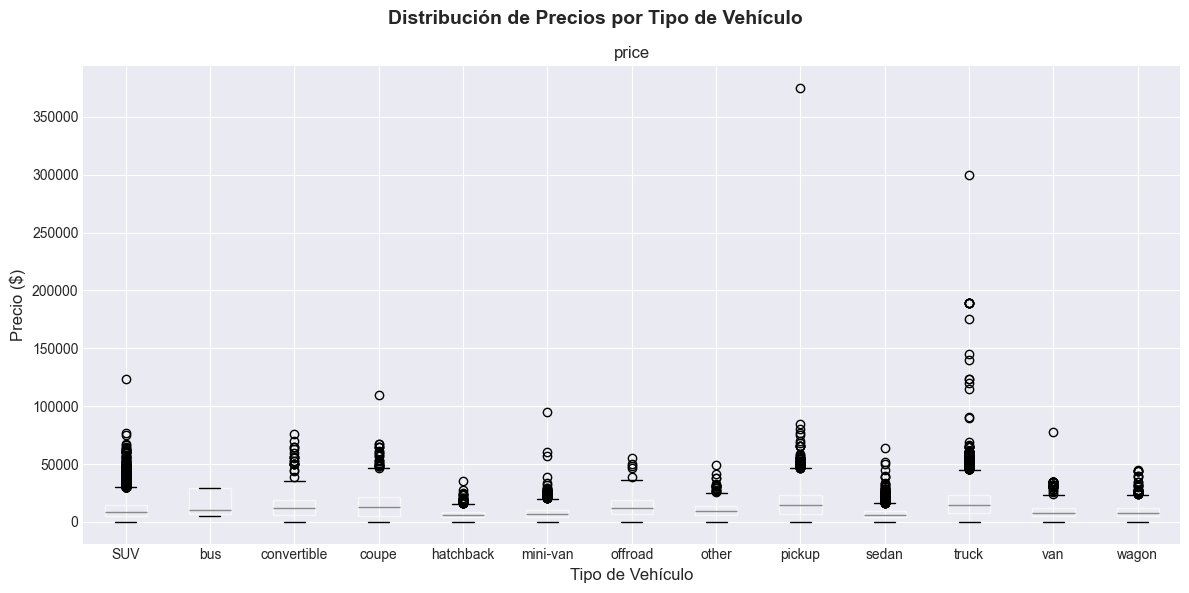

In [15]:
plt.figure(figsize=(12, 6))
df.boxplot(column='price', by='type', figsize=(12, 6))
plt.suptitle('Distribución de Precios por Tipo de Vehículo', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Vehículo', fontsize=12)
plt.ylabel('Precio ($)', fontsize=12)
plt.tight_layout()
plt.show()

### 6.2 Distribución de Tipos (Pie Chart)

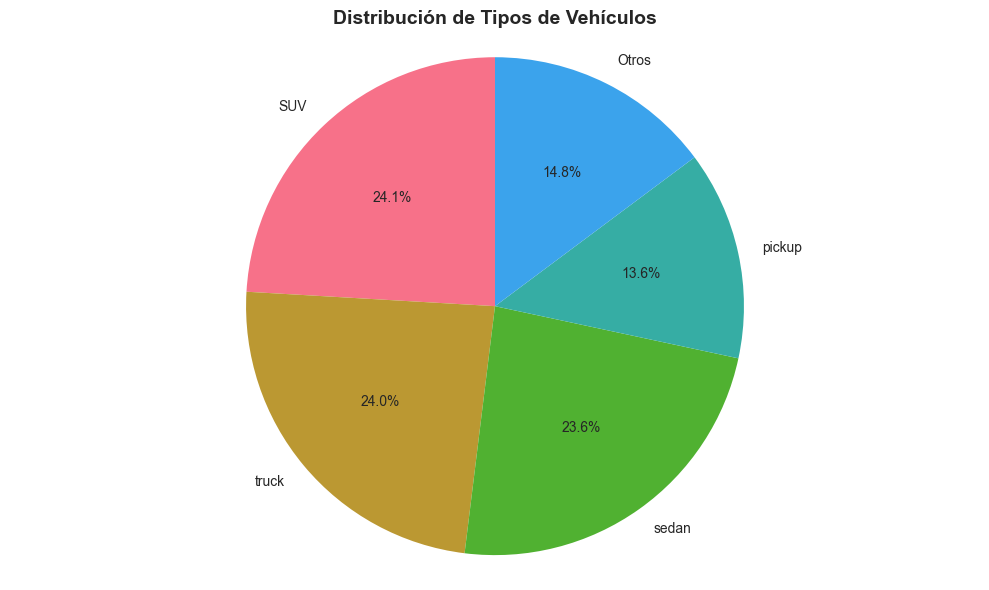

In [16]:
vehicle_counts = df['type'].value_counts()

# Agrupar valores menores o iguales al 5% en "Otros"
total = vehicle_counts.sum()
threshold = total * 0.05
others_count = vehicle_counts[vehicle_counts <= threshold].sum()
vehicle_counts_filtered = vehicle_counts[vehicle_counts > threshold]

if others_count > 0:
    vehicle_counts_filtered['Otros'] = others_count

plt.figure(figsize=(10, 6))
plt.pie(vehicle_counts_filtered.values, labels=vehicle_counts_filtered.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Tipos de Vehículos', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

### 6.3 Matriz de Correlación (Heatmap)

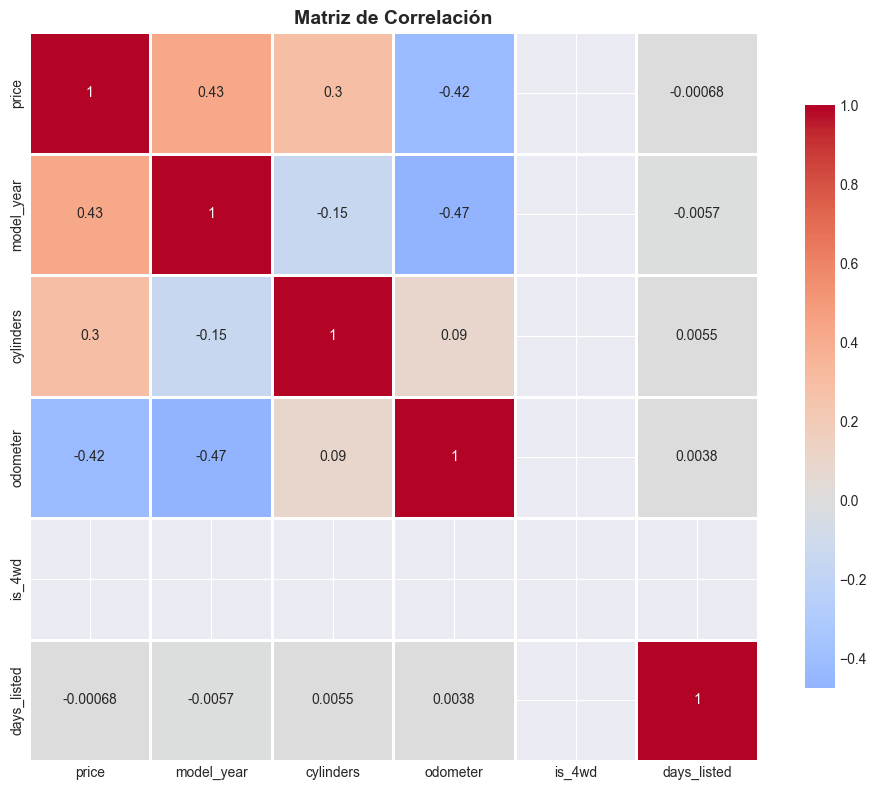

In [17]:
# Seleccionar columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. INSIGHTS CLAVE

In [18]:
print("="*60)
print("INSIGHTS PRINCIPALES")
print("="*60)

print(f"\n1. PRECIOS:")
print(f"   - Precio mínimo: ${df['price'].min():,.0f}")
print(f"   - Precio máximo: ${df['price'].max():,.0f}")
print(f"   - Precio promedio: ${df['price'].mean():,.0f}")
print(f"   - Precio mediano: ${df['price'].median():,.0f}")
print(f"   - Desviación estándar: ${df['price'].std():,.0f}")

print(f"\n2. AÑO DEL MODELO:")
print(f"   - Año mínimo: {df['model_year'].min():.0f}")
print(f"   - Año máximo: {df['model_year'].max():.0f}")
print(f"   - Año promedio: {df['model_year'].mean():.1f}")

print(f"\n3. TIPO DE VEHÍCULO MÁS COMÚN:")
top_type = df['type'].value_counts().index[0]
top_count = df['type'].value_counts().iloc[0]
print(f"   - {top_type}: {top_count} vehículos ({top_count/len(df)*100:.1f}%)")

print(f"\n4. CONDICIÓN MÁS COMÚN:")
top_cond = df['condition'].value_counts().index[0]
top_cond_count = df['condition'].value_counts().iloc[0]
print(f"   - {top_cond}: {top_cond_count} vehículos ({top_cond_count/len(df)*100:.1f}%)")

print(f"\n5. DÍAS LISTADO:")
print(f"   - Promedio: {df['days_listed'].mean():.1f} días")
print(f"   - Mediana: {df['days_listed'].median():.1f} días")
print(f"   - Máximo: {df['days_listed'].max():.1f} días")

print(f"\n6. CILINDROS:")
print(f"   - Promedio: {df['cylinders'].mean():.1f} cilindros")
print(f"   - Más común: {df['cylinders'].mode()[0]:.0f} cilindros")

print("\n" + "="*60)

INSIGHTS PRINCIPALES

1. PRECIOS:
   - Precio mínimo: $1
   - Precio máximo: $375,000
   - Precio promedio: $12,132
   - Precio mediano: $9,000
   - Desviación estándar: $10,041

2. AÑO DEL MODELO:
   - Año mínimo: 1908
   - Año máximo: 2019
   - Año promedio: 2009.8

3. TIPO DE VEHÍCULO MÁS COMÚN:
   - SUV: 12405 vehículos (24.1%)

4. CONDICIÓN MÁS COMÚN:
   - excellent: 24773 vehículos (48.1%)

5. DÍAS LISTADO:
   - Promedio: 39.6 días
   - Mediana: 33.0 días
   - Máximo: 271.0 días

6. CILINDROS:
   - Promedio: 6.1 cilindros
   - Más común: 8 cilindros

